# 比较情绪分析结果（脚本版）

这个 notebook 使用 `compare_results.py` 里的封装函数来复现 `compare_results.ipynb` 的呈现逻辑。

分析内容包括：

- 各结果文件的样本量与字段检查
- 不同结果之间 `id` 交集规模统计
- 各 pair 在交集样本上的 `sentiment_score` 与 `confidence` 对比
- 差值分布、散点图和相关性热图
- 各 pair 差异最大的样本明细

当前默认配置为比较：`4_v2_gemini`、`4_structured_input_gemini`、`4_golden_structured_input_gemini`、`4_golden_structured_input_gpt`。

后续如果你新增了结果目录，只需要修改下一格里的 `RESULT_DATASETS` 和 `PAIRS_TO_COMPARE`。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import compare_results as cr

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

BASE_DIR = Path(r"D:\AQUMON\data\results\4")

RESULT_DATASETS = [
    "4_v2_gemini",
    "4_structured_input_gemini",
    "4_golden_structured_input_gemini",
    "4_golden_structured_input_gpt",
]

PAIRS_TO_COMPARE = [
    ("4_v2_gemini", "4_structured_input_gemini"),
    ("4_v2_gemini", "4_golden_structured_input_gemini"),
    ("4_structured_input_gemini", "4_golden_structured_input_gemini"),
    ("4_golden_structured_input_gemini", "4_golden_structured_input_gpt"),
]

TOP_N_DIFFS = 20

RESULT_FILES = cr.build_result_files_from_names(RESULT_DATASETS, base_dir=BASE_DIR)
RESULT_FILES

{'4_v2_gemini': WindowsPath('D:/AQUMON/data/results/4/4_v2_gemini'),
 '4_structured_input_gemini': WindowsPath('D:/AQUMON/data/results/4/4_structured_input_gemini'),
 '4_golden_structured_input_gemini': WindowsPath('D:/AQUMON/data/results/4/4_golden_structured_input_gemini'),
 '4_golden_structured_input_gpt': WindowsPath('D:/AQUMON/data/results/4/4_golden_structured_input_gpt')}

In [2]:
artifacts = cr.prepare_comparison(
    RESULT_FILES,
    pairs_to_compare=PAIRS_TO_COMPARE,
)

print("Dataset summary")
display(artifacts.dataset_summary)

print("Pairwise overlap summary")
display(artifacts.pairwise_overlap_summary)

for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = artifacts.comparison_tables[(left_name, right_name)]
    print(f"Detailed comparison pair: {left_name} vs {right_name}")
    print(f"Intersection rows: {len(pair_df)}")
    display(pair_df.head())

Dataset summary


,dataset,rows,unique_ids,score_non_null,confidence_non_null,score_mean,confidence_mean,source_path
0,4_golden_structured_input_gemini,54,54,54,54,0.222222,86.481481,D:\AQUMON\data\results\4\4_golden_structured_i...
1,4_golden_structured_input_gpt,54,54,54,54,0.188889,71.814815,D:\AQUMON\data\results\4\4_golden_structured_i...
2,4_structured_input_gemini,54,54,54,54,0.262963,89.166667,D:\AQUMON\data\results\4\4_structured_input_ge...
3,4_v2_gemini,26262,26262,26262,26262,0.046501,88.166057,D:\AQUMON\data\results\4\4_v2_gemini\sentiment...


Pairwise overlap summary


,left,right,left_rows,right_rows,intersection_rows,union_rows,jaccard
0,4_golden_structured_input_gemini,4_golden_structured_input_gpt,54,54,54,54,1.000000
1,4_structured_input_gemini,4_golden_structured_input_gemini,54,54,54,54,1.000000
2,4_structured_input_gemini,4_golden_structured_input_gpt,54,54,54,54,1.000000
3,4_v2_gemini,4_golden_structured_input_gemini,26262,54,54,26262,0.002056
4,4_v2_gemini,4_golden_structured_input_gpt,26262,54,54,26262,0.002056
5,4_v2_gemini,4_structured_input_gemini,26262,54,54,26262,0.002056


Detailed comparison pair: 4_v2_gemini vs 4_structured_input_gemini
Intersection rows: 54


...

,id,sentiment_score_4_v2_gemini,confidence_4_v2_gemini,confidence_pct_4_v2_gemini,summary_4_v2_gemini,sentiment_score_4_golden_structured_input_gemini,confidence_4_golden_structured_input_gemini,confidence_pct_4_golden_structured_input_gemini,summary_4_golden_structured_input_gemini,sentiment_score_diff,sentiment_score_abs_diff,confidence_pct_diff,confidence_pct_abs_diff
0,0001209191-20-015600,0.8,95%,95.0,This filing shows a strong positive insider se...,0.3,80%,80.0,The Chairman and CEO acquired a significant nu...,-0.5,0.5,-15.0,15.0
1,0001209191-22-028778,0.8,95%,95.0,This filing details multiple open-market purch...,0.3,80%,80.0,This filing reports a cluster of five discreti...,-0.5,0.5,-15.0,15.0
2,0001209191-20-016737,0.7,90%,90.0,This filing shows a strongly positive insider ...,0.3,80%,80.0,A director made a discretionary open market pu...,-0.4,0.4,-10.0,10.0
3,0001209191-20-021443,0.3,75%,75.0,This filing indicates a moderately positive in...,0.0,80%,80.0,"This filing reports the acquisition of 5,000 c...",-0.3,0.3,5.0,5.0
4,0000064040-23-000067,-0.3,75%,75.0,This filing suggests a slightly negative senti...,-0.6,75%,75.0,"Saugata Saha, President of Commodity Insights ...",-0.3,0.3,0.0,0.0


Detailed comparison pair: 4_structured_input_gemini vs 4_golden_structured_input_gemini
Intersection rows: 54


,id,sentiment_score_4_structured_input_gemini,confidence_4_structured_input_gemini,confidence_pct_4_structured_input_gemini,summary_4_structured_input_gemini,sentiment_score_4_golden_structured_input_gemini,confidence_4_golden_structured_input_gemini,confidence_pct_4_golden_structured_input_gemini,summary_4_golden_structured_input_gemini,sentiment_score_diff,sentiment_score_abs_diff,confidence_pct_diff,confidence_pct_abs_diff
0,0001209191-22-028778,0.8,95%,95.0,This filing details multiple substantial open-...,0.3,80%,80.0,This filing reports a cluster of five discreti...,-0.5,0.5,-15.0,15.0
1,0001209191-20-015600,0.7,95%,95.0,This filing suggests a strongly positive insid...,0.3,80%,80.0,The Chairman and CEO acquired a significant nu...,-0.4,0.4,-15.0,15.0
2,0001209191-18-061223,-0.3,85%,85.0,The CEO and Chairman exercised a substantial n...,0.0,90%,90.0,"This filing shows the Chairman, President & CE...",0.3,0.3,5.0,5.0
3,0000064040-23-000067,-0.3,80%,80.0,This filing indicates a slightly negative insi...,-0.6,75%,75.0,"Saugata Saha, President of Commodity Insights ...",-0.3,0.3,-5.0,5.0
4,0000933036-21-000095,0.7,90%,90.0,This filing indicates a strongly positive sent...,0.4,70%,70.0,"Director Jeffrey J. Brown made a large, discre...",-0.3,0.3,-20.0,20.0


Detailed comparison pair: 4_golden_structured_input_gemini vs 4_golden_structured_input_gpt
Intersection rows: 54


,id,sentiment_score_4_golden_structured_input_gemini,confidence_4_golden_structured_input_gemini,confidence_pct_4_golden_structured_input_gemini,summary_4_golden_structured_input_gemini,sentiment_score_4_golden_structured_input_gpt,confidence_4_golden_structured_input_gpt,confidence_pct_4_golden_structured_input_gpt,summary_4_golden_structured_input_gpt,sentiment_score_diff,sentiment_score_abs_diff,confidence_pct_diff,confidence_pct_abs_diff
0,0000899243-20-008213,0.9,95%,95.0,Chief Financial Officer George L. Ball execute...,0.4,85%,85.0,Chief Financial Officer George L. Ball purchas...,-0.5,0.5,-10.0,10.0
1,0001209191-20-021443,0.0,80%,80.0,"This filing reports the acquisition of 5,000 c...",0.4,80%,80.0,SVP of Worldwide Operations Wong Hing Chung pu...,0.4,0.4,0.0,0.0
2,0000919574-20-002399,0.7,90%,90.0,A director acquired a very large volume of com...,0.3,70%,70.0,Director Robert J. Small reported purchases of...,-0.4,0.4,-20.0,20.0
3,0000899243-20-008612,0.7,90%,90.0,"Harry T. McMahon, a Director at PARSONS CORP, ...",0.3,80%,80.0,Director Harry T. McMahon reported three conse...,-0.4,0.4,-10.0,10.0
4,0001209191-20-020278,0.8,95%,95.0,"The Chief Strategy Officer, who is also a Dire...",0.5,85%,85.0,Chief Strategy Officer and Director Hezy Shake...,-0.3,0.3,-10.0,10.0


In [3]:
for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = artifacts.comparison_tables[(left_name, right_name)]
    summary_stats = cr.build_pair_summary_stats(pair_df, left_name, right_name)

    print(f"Summary stats: {left_name} vs {right_name}")
    display(summary_stats)

    if len(pair_df) < 2:
        print("Warning: 当前交集样本数小于 2，相关性统计没有解释意义。")

Summary stats: 4_v2_gemini vs 4_structured_input_gemini


,metric,value
0,intersection_rows,54.000000
1,mean_sentiment_score_4_v2_gemini,0.253704
2,mean_sentiment_score_4_structured_input_gemini,0.262963
3,mean_sentiment_score_abs_diff,0.068519
4,mean_confidence_pct_4_v2_gemini,88.870370
5,mean_confidence_pct_4_structured_input_gemini,89.166667
6,mean_confidence_pct_abs_diff,3.555556
7,sentiment_score_corr,0.956127
8,confidence_pct_corr,0.497728


Summary stats: 4_v2_gemini vs 4_golden_structured_input_gemini


,metric,value
0,intersection_rows,54.000000
1,mean_sentiment_score_4_v2_gemini,0.253704
2,mean_sentiment_score_4_golden_structured_input...,0.222222
3,mean_sentiment_score_abs_diff,0.090741
4,mean_confidence_pct_4_v2_gemini,88.870370
5,mean_confidence_pct_4_golden_structured_input_...,86.481481
6,mean_confidence_pct_abs_diff,5.685185
7,sentiment_score_corr,0.907747
8,confidence_pct_corr,0.335950


Summary stats: 4_structured_input_gemini vs 4_golden_structured_input_gemini


,metric,value
0,intersection_rows,54.000000
1,mean_sentiment_score_4_structured_input_gemini,0.262963
2,mean_sentiment_score_4_golden_structured_input...,0.222222
3,mean_sentiment_score_abs_diff,0.070370
4,mean_confidence_pct_4_structured_input_gemini,89.166667
5,mean_confidence_pct_4_golden_structured_input_...,86.481481
6,mean_confidence_pct_abs_diff,7.129630
7,sentiment_score_corr,0.947296
8,confidence_pct_corr,0.019832


Summary stats: 4_golden_structured_input_gemini vs 4_golden_structured_input_gpt


,metric,value
0,intersection_rows,54.000000
1,mean_sentiment_score_4_golden_structured_input...,0.222222
2,mean_sentiment_score_4_golden_structured_input...,0.188889
3,mean_sentiment_score_abs_diff,0.096296
4,mean_confidence_pct_4_golden_structured_input_...,86.481481
5,mean_confidence_pct_4_golden_structured_input_gpt,71.814815
6,mean_confidence_pct_abs_diff,15.518519
7,sentiment_score_corr,0.896576
8,confidence_pct_corr,0.113665


Plots for: 4_v2_gemini vs 4_structured_input_gemini


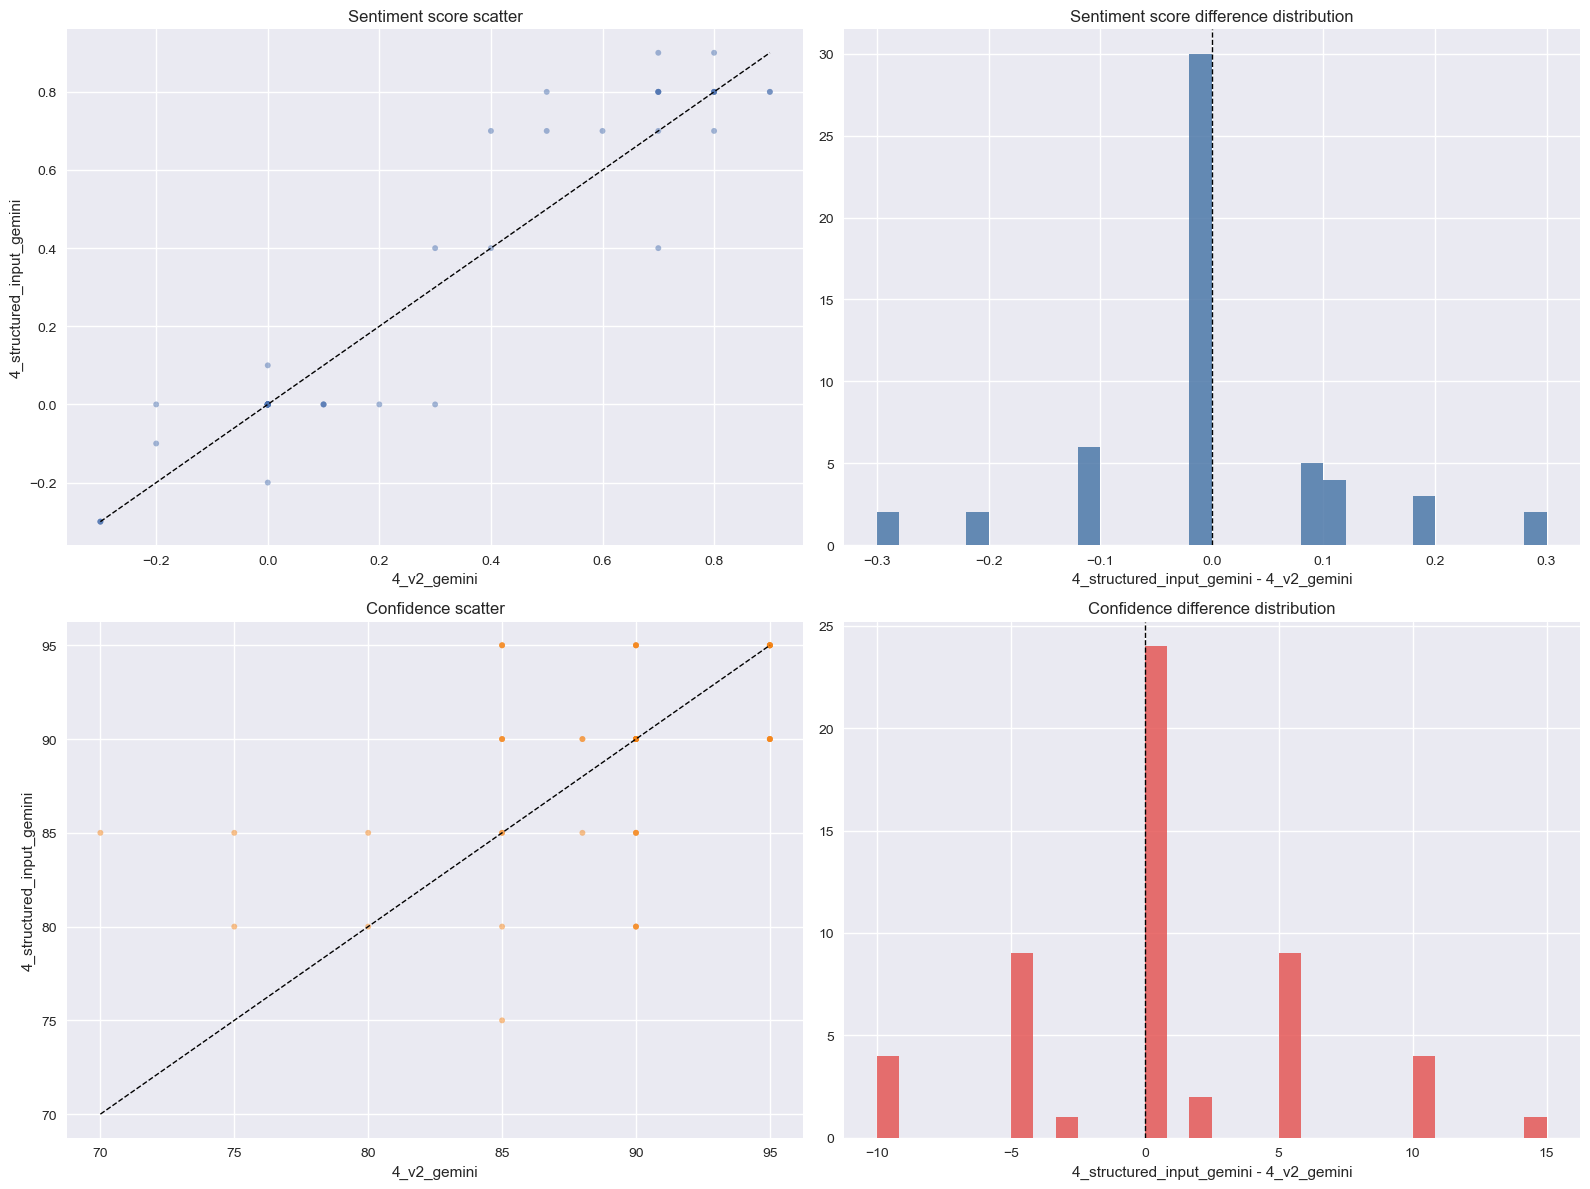

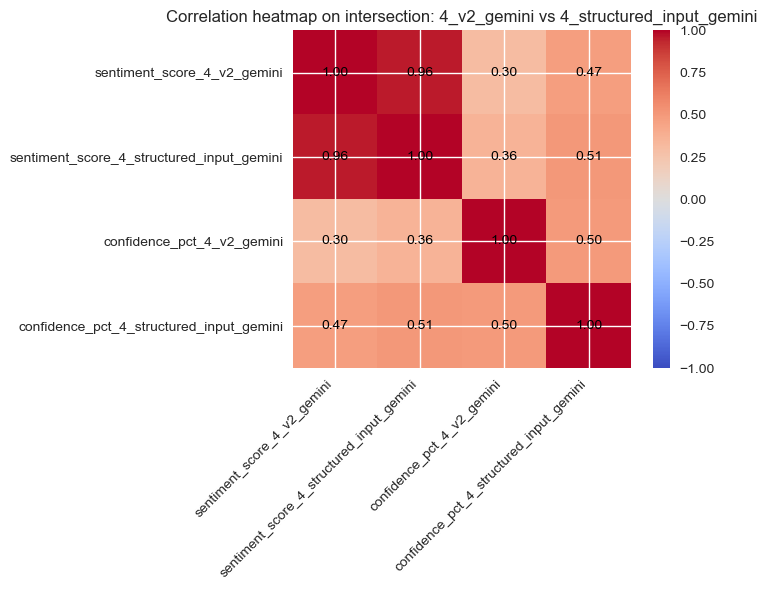

Plots for: 4_v2_gemini vs 4_golden_structured_input_gemini


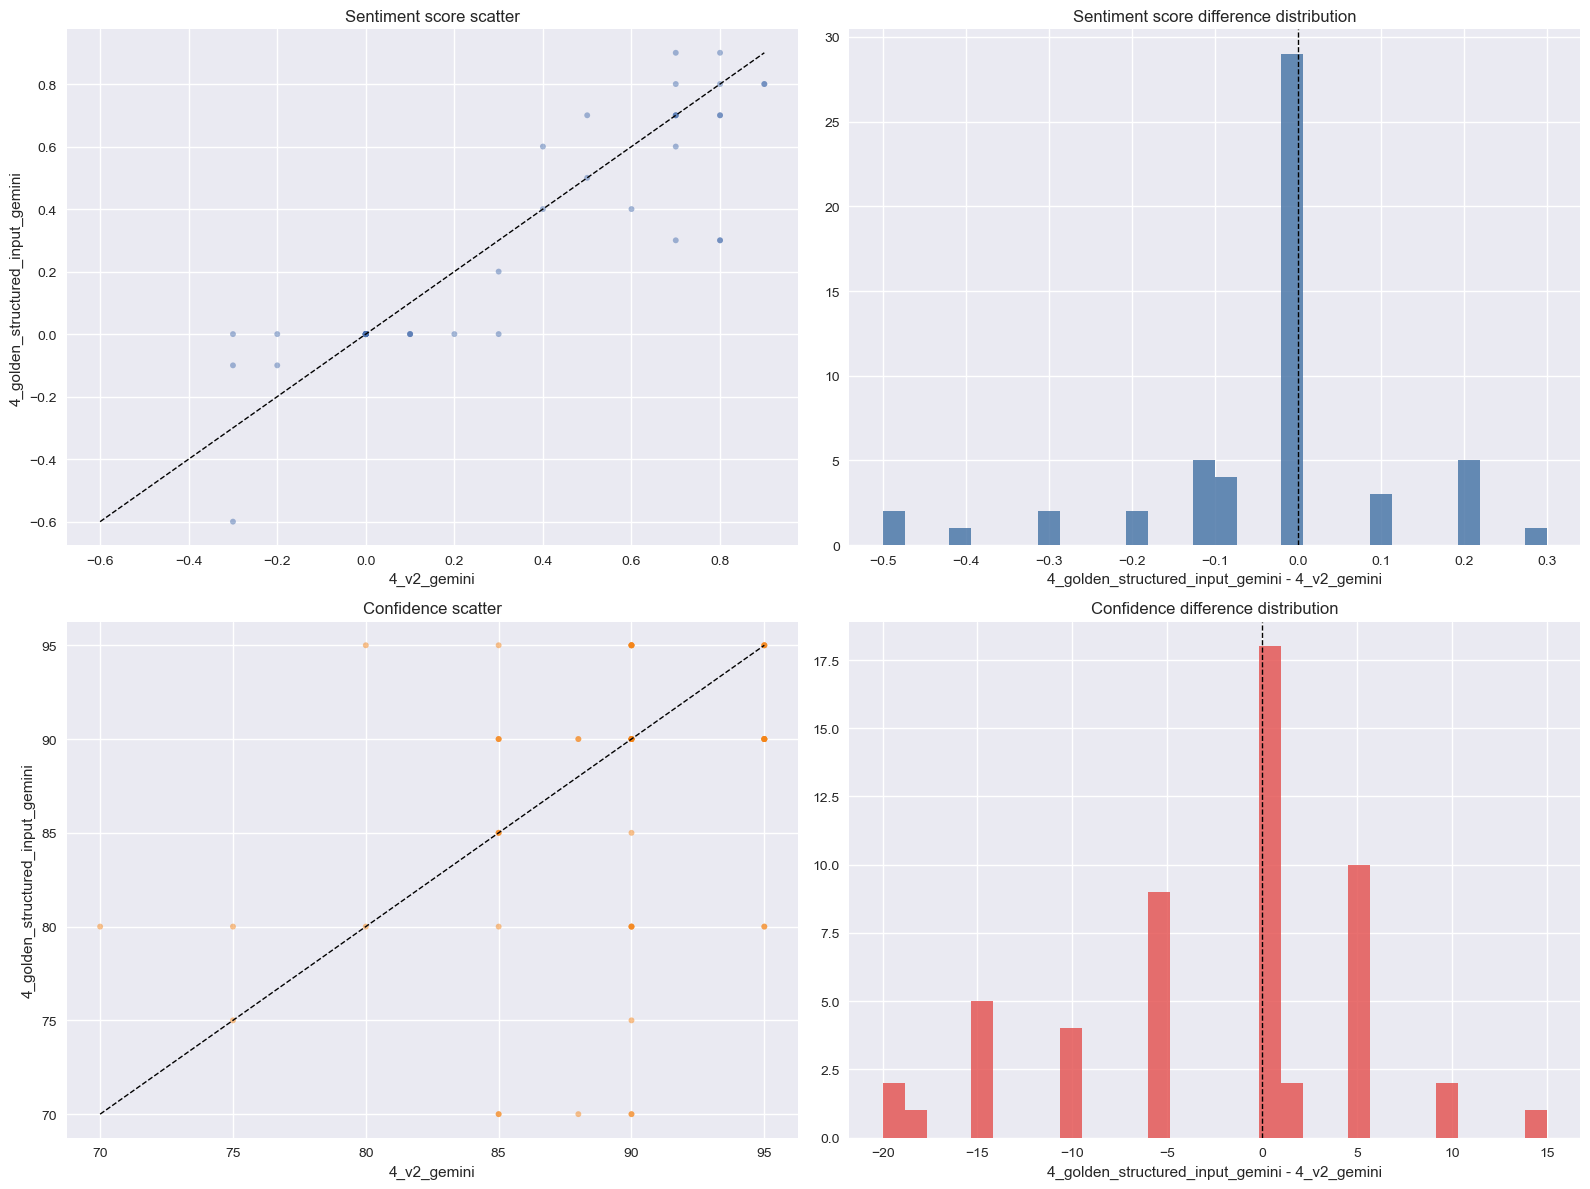

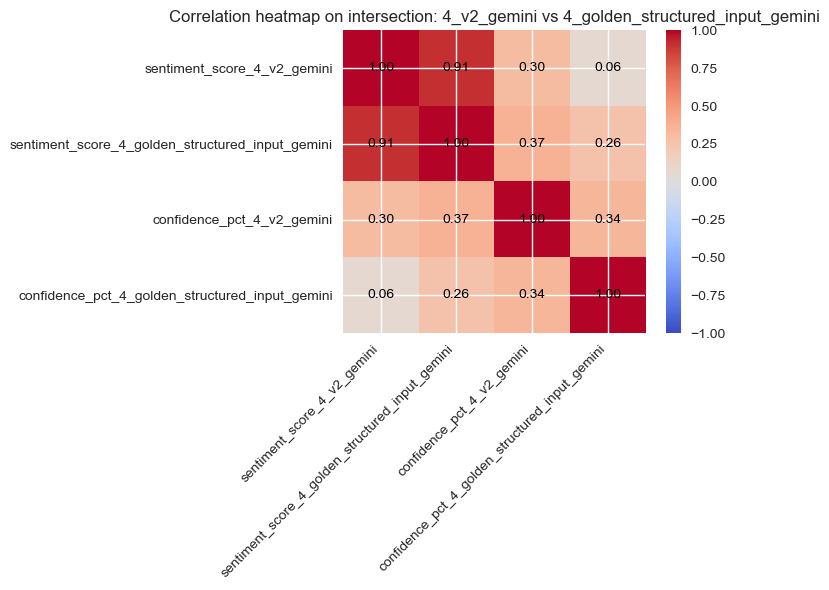

Plots for: 4_structured_input_gemini vs 4_golden_structured_input_gemini


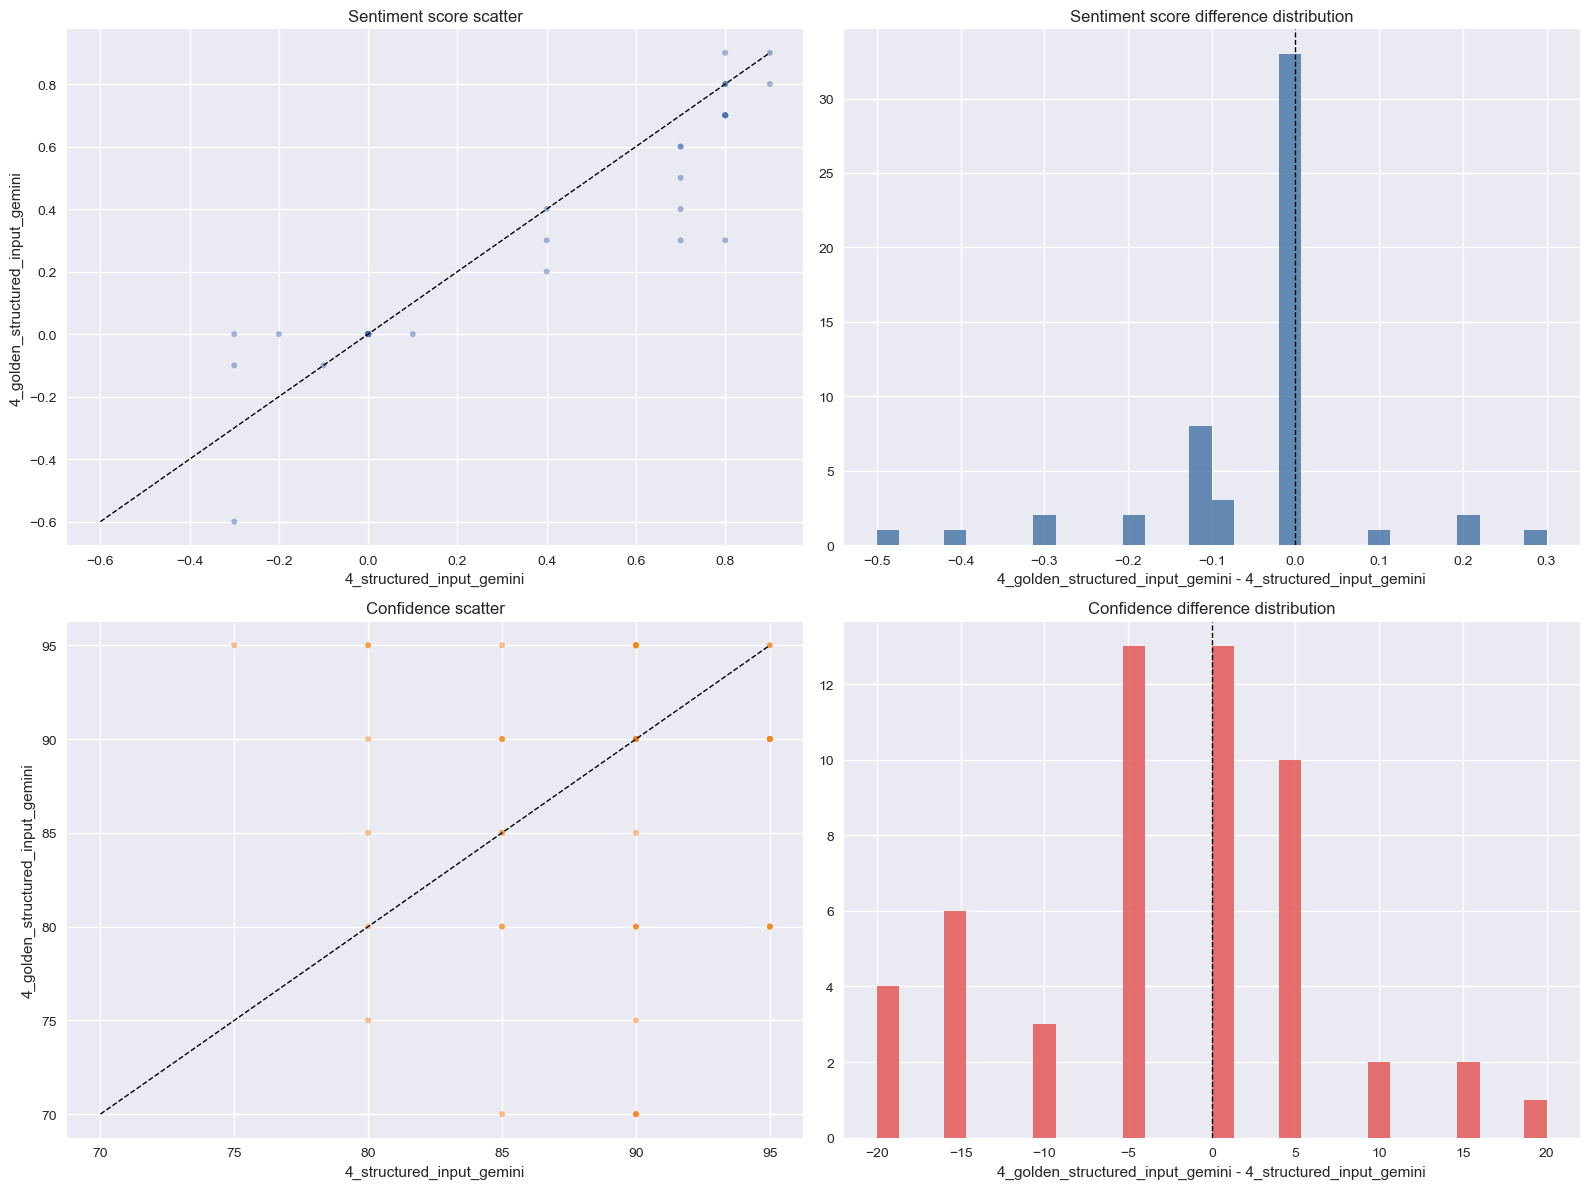

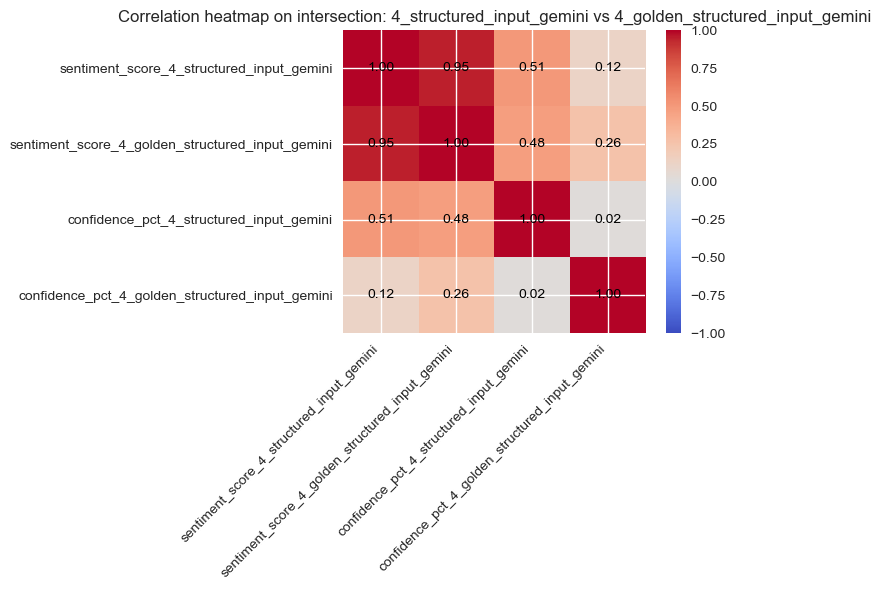

Plots for: 4_golden_structured_input_gemini vs 4_golden_structured_input_gpt


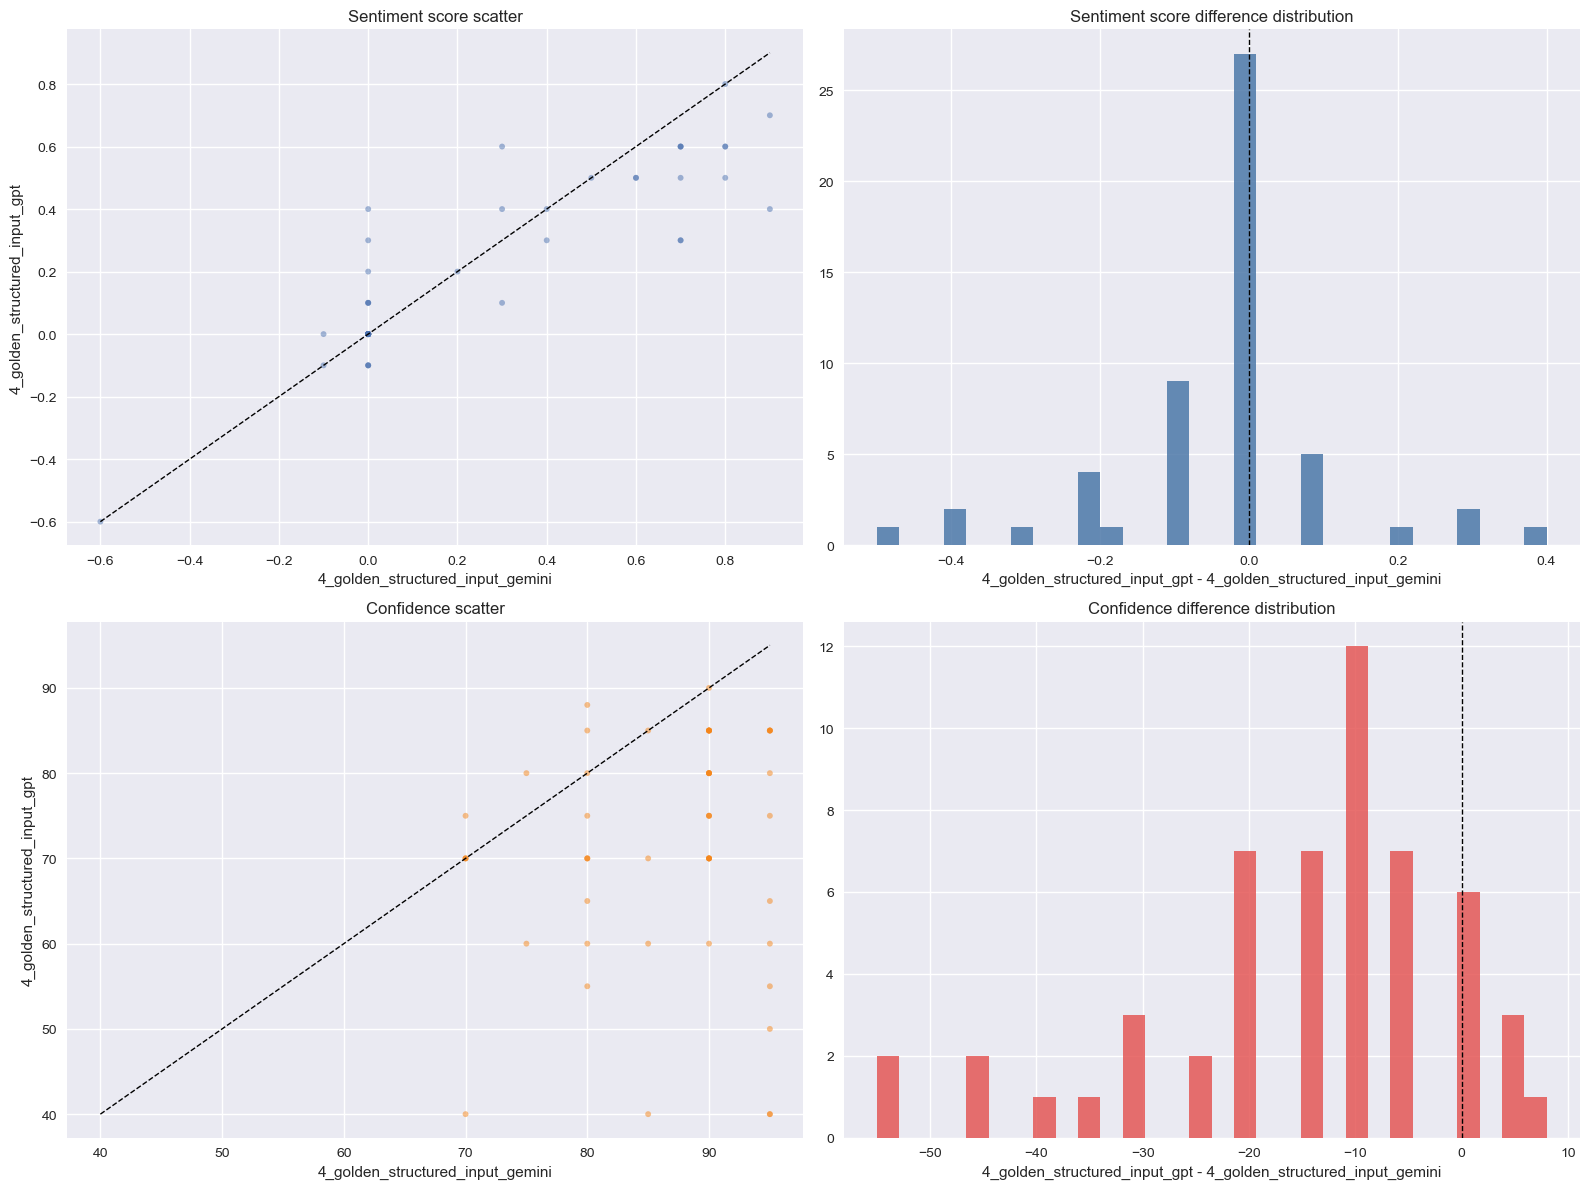

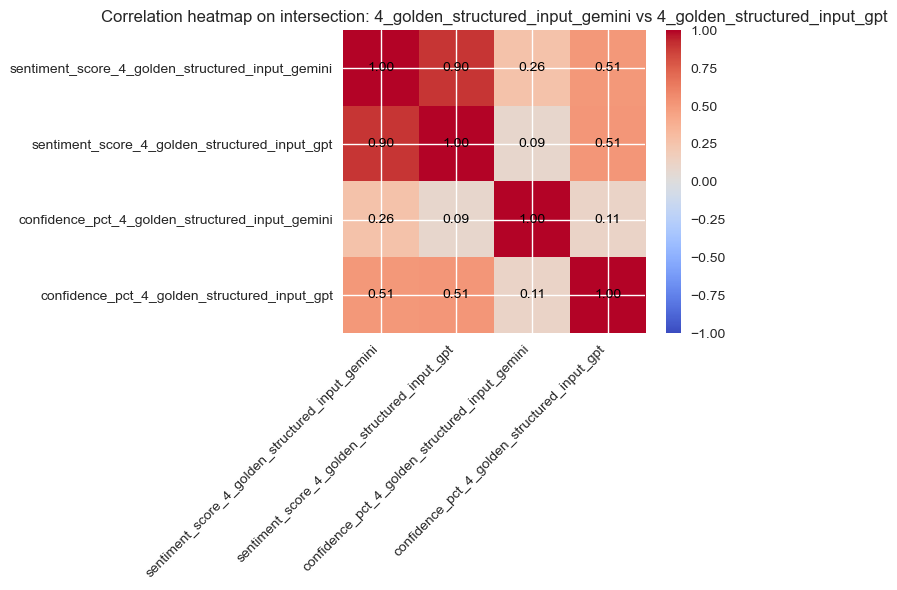

In [4]:
for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = artifacts.comparison_tables[(left_name, right_name)]
    print(f"Plots for: {left_name} vs {right_name}")

    if pair_df.empty:
        print("Skipped plots because the intersection is empty.")
        continue

    plot_artifacts = cr.plot_pair_diagnostics(pair_df, left_name, right_name)

    if plot_artifacts["heatmap"] is None:
        print("Skipped correlation heatmap because the intersection has fewer than 2 rows.")

In [5]:
for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = artifacts.comparison_tables[(left_name, right_name)]
    print(f"Top {TOP_N_DIFFS} differences: {left_name} vs {right_name}")

    if pair_df.empty:
        print("Skipped detailed diff tables because the intersection is empty.")
        continue

    top_tables = cr.get_top_differences(pair_df, left_name, right_name, top_n=TOP_N_DIFFS)

    print(f"Top {TOP_N_DIFFS} sentiment_score differences")
    display(top_tables["top_score_diffs"])

    print(f"Top {TOP_N_DIFFS} confidence differences")
    display(top_tables["top_confidence_diffs"])

Top 20 differences: 4_v2_gemini vs 4_structured_input_gemini
Top 20 sentiment_score differences


,id,sentiment_score_4_v2_gemini,sentiment_score_4_structured_input_gemini,sentiment_score_diff,confidence_pct_4_v2_gemini,confidence_pct_4_structured_input_gemini,summary_4_v2_gemini,summary_4_structured_input_gemini
0,0001213900-24-034233,0.5,0.8,0.3,85.0,95.0,This filing indicates a moderately positive se...,This filing indicates a strongly positive insi...
1,0001209191-20-021443,0.3,0.0,-0.3,75.0,85.0,This filing indicates a moderately positive in...,"This filing reports an SVP exercising 5,000 em..."
2,0001209191-20-021889,0.4,0.7,0.3,95.0,95.0,This filing reflects a moderately positive ins...,This filing indicates a strongly positive insi...
3,0001209191-20-016737,0.7,0.4,-0.3,90.0,90.0,This filing shows a strongly positive insider ...,This filing reflects a moderately positive ins...
4,0000899243-20-008213,0.7,0.9,0.2,90.0,95.0,This filing indicates a strongly positive sent...,This filing demonstrates strongly positive ins...
5,0001209191-20-019874,0.0,-0.2,-0.2,80.0,85.0,The filing presents a neutral sentiment as it ...,"This filing presents a mixed signal, leaning s..."
6,0001209191-22-045612,-0.2,0.0,0.2,88.0,85.0,This filing details a sale of 400 shares by th...,This filing reports a sale of common stock by ...
7,0001209191-20-024112,0.2,0.0,-0.2,80.0,80.0,This filing suggests a slightly positive insid...,This filing reports a Director's acquisition o...
8,0001534701-20-000072,0.5,0.7,0.2,85.0,90.0,This filing indicates a moderately positive in...,This filing reflects strongly positive insider...
9,0000899243-20-008612,0.7,0.8,0.1,88.0,90.0,This filing suggests a strong positive sentime...,This filing suggests a strongly positive insid...


Top 20 confidence differences


,id,confidence_pct_4_v2_gemini,confidence_pct_4_structured_input_gemini,confidence_pct_diff,sentiment_score_4_v2_gemini,sentiment_score_4_structured_input_gemini,summary_4_v2_gemini,summary_4_structured_input_gemini
15,0001127602-20-011102,70.0,85.0,15.0,0.1,0.0,This filing indicates a slightly positive sent...,"EVP, President and COO Gary S. Bedard reported..."
0,0001213900-24-034233,85.0,95.0,10.0,0.5,0.8,This filing indicates a moderately positive se...,This filing indicates a strongly positive insi...
1,0001209191-20-021443,75.0,85.0,10.0,0.3,0.0,This filing indicates a moderately positive in...,"This filing reports an SVP exercising 5,000 em..."
16,0001209191-20-018902,85.0,75.0,-10.0,0.0,0.1,This filing reports the grant of Restricted St...,This filing discloses the acquisition of a sub...
24,0001701605-18-000067,90.0,80.0,-10.0,0.0,0.0,This filing indicates a neutral insider sentim...,This filing reports the acquisition of Restric...
25,0001209191-22-030998,90.0,80.0,-10.0,0.0,0.0,This filing indicates a neutral sentiment as i...,"This filing reports the award of 9,724 Non-Qua..."
26,0001209191-20-017245,90.0,80.0,-10.0,0.4,0.4,This filing suggests slightly positive insider...,A Senior Executive Vice President and Head of ...
27,0000933036-21-000014,85.0,95.0,10.0,0.0,0.0,This filing reflects a neutral sentiment as th...,This filing reflects a neutral sentiment as th...
28,0000740260-22-000089,85.0,95.0,10.0,0.0,0.0,This filing conveys a neutral sentiment becaus...,This filing implies a neutral sentiment as the...
4,0000899243-20-008213,90.0,95.0,5.0,0.7,0.9,This filing indicates a strongly positive sent...,This filing demonstrates strongly positive ins...


Top 20 differences: 4_v2_gemini vs 4_golden_structured_input_gemini
Top 20 sentiment_score differences


...

,id,confidence_pct_4_structured_input_gemini,confidence_pct_4_golden_structured_input_gemini,confidence_pct_diff,sentiment_score_4_structured_input_gemini,sentiment_score_4_golden_structured_input_gemini,summary_4_structured_input_gemini,summary_4_golden_structured_input_gemini
4,0000933036-21-000095,90.0,70.0,-20.0,0.7,0.4,This filing indicates a strongly positive sent...,"Director Jeffrey J. Brown made a large, discre..."
5,0001209191-20-018455,90.0,70.0,-20.0,0.4,0.2,Director William Henderson Cameron made an ope...,This filing reports a discretionary purchase o...
16,0001209191-20-018902,75.0,95.0,20.0,0.1,0.0,This filing discloses the acquisition of a sub...,The Chief Executive Officer Executive Chairman...
21,0001209191-20-022145,90.0,70.0,-20.0,0.0,0.0,This filing indicates a neutral insider sentim...,This filing reports the acquisition of deferre...
22,0001209191-20-025445,90.0,70.0,-20.0,0.0,0.0,This filing reports an acquisition of common s...,"This filing reports the acquisition of 12,858 ..."
0,0001209191-22-028778,95.0,80.0,-15.0,0.8,0.3,This filing details multiple substantial open-...,This filing reports a cluster of five discreti...
1,0001209191-20-015600,95.0,80.0,-15.0,0.7,0.3,This filing suggests a strongly positive insid...,The Chairman and CEO acquired a significant nu...
23,0000018230-19-000102,85.0,70.0,-15.0,0.0,0.0,The filing reports an acquisition of common st...,A director acquired shares at a price of zero....
24,0001701605-18-000067,80.0,95.0,15.0,0.0,0.0,This filing reports the acquisition of Restric...,This filing details a Director's acquisition o...
25,0001209191-20-017945,95.0,80.0,-15.0,0.0,0.0,"Carin L. Fike, Vice President and Treasurer, e...",This filing reports acquisitions via option ex...


Top 20 differences: 4_golden_structured_input_gemini vs 4_golden_structured_input_gpt
Top 20 sentiment_score differences


,id,sentiment_score_4_golden_structured_input_gemini,sentiment_score_4_golden_structured_input_gpt,sentiment_score_diff,confidence_pct_4_golden_structured_input_gemini,confidence_pct_4_golden_structured_input_gpt,summary_4_golden_structured_input_gemini,summary_4_golden_structured_input_gpt
0,0000899243-20-008213,0.9,0.4,-0.5,95.0,85.0,Chief Financial Officer George L. Ball execute...,Chief Financial Officer George L. Ball purchas...
1,0001209191-20-021443,0.0,0.4,0.4,80.0,80.0,"This filing reports the acquisition of 5,000 c...",SVP of Worldwide Operations Wong Hing Chung pu...
2,0000919574-20-002399,0.7,0.3,-0.4,90.0,70.0,A director acquired a very large volume of com...,Director Robert J. Small reported purchases of...
3,0000899243-20-008612,0.7,0.3,-0.4,90.0,80.0,"Harry T. McMahon, a Director at PARSONS CORP, ...",Director Harry T. McMahon reported three conse...
4,0001209191-20-020278,0.8,0.5,-0.3,95.0,85.0,"The Chief Strategy Officer, who is also a Dire...",Chief Strategy Officer and Director Hezy Shake...
5,0001127602-20-011102,0.0,0.3,0.3,80.0,70.0,This filing reports an acquisition of shares (...,"The filing records a net purchase of 2,108 sha..."
6,0001209191-20-015600,0.3,0.6,0.3,80.0,88.0,The Chairman and CEO acquired a significant nu...,"John B. Hess, Chairman and CEO, purchased a to..."
7,0001506307-20-000089,0.8,0.6,-0.2,90.0,85.0,This filing reports a significant discretionar...,"Richard D. Kinder, Executive Chairman, acquire..."
8,0001127602-20-009718,0.9,0.7,-0.2,90.0,85.0,"President and CEO Stephen Kaufer made a large,...","CEO Stephen Kaufer purchased 44,444 shares of ..."
9,0001705696-20-000072,0.8,0.6,-0.2,90.0,85.0,President and COO John W. R. Payne executed a ...,President and COO John W. R. Payne acquired 17...


Top 20 confidence differences


,id,confidence_pct_4_golden_structured_input_gemini,confidence_pct_4_golden_structured_input_gpt,confidence_pct_diff,sentiment_score_4_golden_structured_input_gemini,sentiment_score_4_golden_structured_input_gpt,summary_4_golden_structured_input_gemini,summary_4_golden_structured_input_gpt
27,0001209191-20-019874,95.0,40.0,-55.0,0.0,0.0,President Gregory R. Raifman reported two mech...,The insider’s filing shows a direct purchase o...
28,0000759944-20-000054,95.0,40.0,-55.0,0.0,0.0,A director received a restricted stock unit aw...,"Director Hanna Howard received a grant of 6,41..."
29,0001701605-18-000067,95.0,50.0,-45.0,0.0,0.0,This filing details a Director's acquisition o...,The Baker Hughes director received an award of...
30,0001209191-22-040221,85.0,40.0,-45.0,0.0,0.0,"A director acquired phantom stock units, a der...",Director Juan Enriquez was allocated 431 phant...
31,0001209191-22-030998,95.0,55.0,-40.0,0.0,0.0,"Director Shalini Sharp was awarded 9,724 non-q...","Director Sharp Shalini exercised 9,724 non‑qua..."
32,0001127602-20-010778,95.0,60.0,-35.0,0.0,0.0,The Chief Financial Officer reported a disposi...,"The Arrow Electronics CFO reported selling 1,9..."
15,0001020569-22-000056,95.0,65.0,-30.0,0.0,-0.1,An SVP & Chief Accounting Officer acquired sha...,"The filing includes a vesting award of 1,334 p..."
33,0001209191-20-021012,90.0,60.0,-30.0,0.0,0.0,This filing reports a Chief Financial Officer'...,The Autodesk CFO reported a performance‑stock‑...
34,0000018230-19-000102,70.0,40.0,-30.0,0.0,0.0,A director acquired shares at a price of zero....,Director Juan Gallardo received an acquisition...
35,0001209191-20-017945,80.0,55.0,-25.0,0.0,0.0,This filing reports acquisitions via option ex...,The filing shows simultaneous purchases and sa...
